# generate_derived_solar_fields 模块演示与验证

本 Notebook 做两件事：

1. **演示怎么用**：读取已预处理的测试数据，调用两个算法，看输入/输出长什么样。
2. **验证算得对不对**：把迁移后的结果，和原 IMPROVER 方法、官方样例（KGO）做数值对比。

两个算法分别是：

- `GenerateSolarTime`：在目标网格上算**地方太阳时**（单位小时，0–24）。同一时刻，东边比西边更“晚”，所以结果主要随经度变化。
- `GenerateClearskySolarRadiation`：在指定累积时段内，估算晴空太阳辐射累计量（单位 W s m-2）。可以只给网格，也可以再给海拔和 Linke 浑浊度，让结果更接近真实大气。

官方样例是**投影坐标**，KGO 也是投影结果，所以**先看投影坐标输入**。
官方输入文件本身没有 time 维；预处理已经从 KGO 把计算时刻写进 meb，Notebook 只读盘。

请先在仓库根目录运行一次预处理：

```text
python generate_derived_solar_fields/cli/preprocess_test_data.py
```


## 1. 环境准备

下面几行只做三件事：找到本模块目录、让 Python 能 import 本仓库代码、打开中文绘图。


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import numpy as np
import xarray as xr
import iris
import meteva_base as meb

# 屏蔽第三方库的过时提示，避免干扰阅读输出
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# 图里的中文、负号能正常显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (14, 4)

# 本 Notebook 一般从 generate_derived_solar_fields/nbs/ 打开
PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"
TEST_ROOT = PACKAGE_ROOT / "test_data"

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

# 旧版 IMPROVER 晴空辐射积分仍可能调用已移除的 np.trapz；新 NumPy 改名为 trapezoid
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

# 迁移后方法（读 meb 六维）
from generate_derived_solar_fields.src.generate_derived_solar_fields import (
    GenerateSolarTime,
    GenerateClearskySolarRadiation,
)

# 原 IMPROVER 方法（读 Iris Cube），用来对照
from improver.generate_ancillaries.generate_derived_solar_fields import (  # pyright: ignore[reportMissingImports]
    GenerateSolarTime as OrigGenerateSolarTime,
    GenerateClearskySolarRadiation as OrigGenerateClearskySolarRadiation,
)

print("模块目录:", PACKAGE_ROOT)


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


模块目录: D:\workspace\improver\generate_derived_solar_fields


## 2. 读数、对比用的小工具

后面会反复读文件、把场压成二维、打印误差。先写成函数，正文里只保留“读哪些文件、调用哪个算法”。


In [2]:
def require_files(paths, label: str) -> None:
    """缺文件时给出明确提示，避免后面读盘才报一长串错误。"""
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少{label}（共 {len(missing)} 个）。"
            "请先运行: python generate_derived_solar_fields/cli/preprocess_test_data.py\n"
            + "\n".join(missing[:8])
        )


def to_2d_values(data) -> np.ndarray:
    """把六维场或 Cube 压成一张二维图，方便比数值、画图。"""
    # 原 IMPROVER / 官方结果经常是 Iris Cube
    if hasattr(data, "data") and not isinstance(data, xr.DataArray):
        raw = data.data
        arr = (
            np.ma.filled(np.ma.asarray(raw, dtype=np.float64), np.nan)
            if np.ma.isMaskedArray(raw)
            else np.asarray(raw, dtype=np.float64)
        )
        return np.squeeze(arr)
    # meb 六维：前几维通常长度为 1，去掉后得到 lat×lon
    arr = data
    for dim in list(arr.dims):
        if dim not in (
            "lat",
            "lon",
            "latitude",
            "longitude",
            "projection_y_coordinate",
            "projection_x_coordinate",
        ):
            arr = arr.isel({dim: 0}, drop=True)
    return np.squeeze(np.asarray(arr.values, dtype=np.float64))


def compare_stats(current, reference, tag: str):
    """打印两个场的差异。三个数都接近 0，说明两边几乎一样。"""
    c = to_2d_values(current)
    r = to_2d_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"二维场形状不一致: current={c.shape}, reference={r.shape}")
    diff = c - r
    print(
        f"[{tag}] "
        f"平均绝对误差={np.mean(np.abs(diff)):.6f}, "
        f"最大绝对误差={np.max(np.abs(diff)):.6f}, "
        f"均方根误差={np.sqrt(np.mean(diff**2)):.6f}"
    )
    return c, r, diff


def infer_accumulation_hours_from_kgo(kgo_path: Path) -> int:
    """从 KGO 的 time_bnds 推出晴空辐射应累积多少小时，避免手写与官方样例不一致。"""
    ds = xr.open_dataset(kgo_path, decode_timedelta=False)
    try:
        if "time_bnds" not in ds:
            return 1
        b = ds["time_bnds"].values
        if b.size < 2:
            return 1
        delta_hours = int(
            (np.datetime64(b.reshape(-1)[1]) - np.datetime64(b.reshape(-1)[0])) / np.timedelta64(1, "h")
        )
        return max(delta_hours, 1)
    finally:
        ds.close()


print("工具函数已就绪。")


工具函数已就绪。


## 3. 投影坐标输入


### 3.1 GenerateSolarTime

地方太阳时主要随经度变化：同一世界时，东边的地方时更大。输出单位是小时，范围 0–24。


#### 输入数据绘图

太阳时算法真正用的是网格经纬度；这里画出目标网格上的地形，方便对照空间范围。


In [3]:
solar_root = TEST_ROOT / "generate-solar-time"
solar_meb_path = solar_root / "cli_inputs" / "input_target_grid_meb.nc"
require_files([solar_meb_path],"投影坐标 meb")
# 修改后方法输入数据
solar_target_grid = meb.read_griddata_from_nc(solar_meb_path)

# 预处理已把 KGO 时刻写入 meb 的 time 维，这里取出来给算法
solar_valid_time = str(
    np.datetime_as_string(np.asarray(solar_target_grid.coords["time"].values).ravel()[0], unit="s")
)
solar_valid_time_dt = datetime.fromisoformat(solar_valid_time)

# 原方法输入：原始测试数据
solar_target_cube = iris.load_cube(str(solar_root / "surface_altitude.nc"))

print("solar_valid_time:", solar_valid_time)
print("solar_target_grid:", solar_target_grid.shape, solar_target_grid.dims)
print("solar_target_cube:", solar_target_cube.shape, solar_target_cube.name())

solar_valid_time: 2022-06-07T00:00:00
solar_target_grid: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')
solar_target_cube: (103, 155) surface_altitude


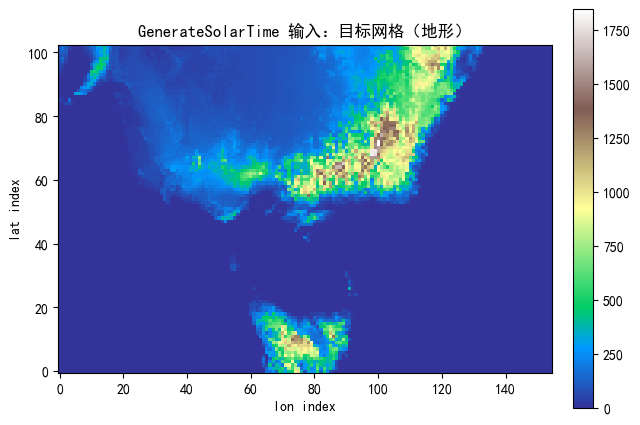

In [4]:
# 输入数据绘图：目标网格（地形）
solar_input_2d = to_2d_values(solar_target_grid)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
im = ax.imshow(solar_input_2d, origin="lower", cmap="terrain")
ax.set_title("GenerateSolarTime 输入：目标网格（地形）")
ax.set_xlabel("lon index")
ax.set_ylabel("lat index")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### 算法运行与数值对比

先创建对象再调用。`new_title` 只改输出属性里的标题，不改变数值，用来确认参数能透传。


In [5]:
# 迁移方法：目标网格 + 计算时刻
solar_current_basic = GenerateSolarTime().process(
    target_grid=solar_target_grid,
    time=solar_valid_time_dt,
)

# 确认 new_title 会写进输出 attrs
solar_current_new_title = GenerateSolarTime().process(
    target_grid=solar_target_grid,
    time=solar_valid_time_dt,
    new_title="demo_new_title",
)
assert solar_current_new_title.attrs.get("title") == "demo_new_title"

# 原方法现场调用（Iris Cube），再转成 DataArray 方便对比
solar_original_basic = OrigGenerateSolarTime().process(solar_target_cube, solar_valid_time_dt)

solar_kgo_basic = iris.load_cube(str(solar_root / "basic" / "kgo.nc"))

c_solar, k_solar, d_solar_ck = compare_stats(
    solar_current_basic, solar_kgo_basic, "solar 修改后方法 vs KGO"
)
_, o_solar, d_solar_co = compare_stats(
    solar_current_basic, solar_original_basic, "solar 修改后方法 vs 原方法"
)
_, _, d_solar_ok = compare_stats(
    solar_original_basic, solar_kgo_basic, "solar 原方法 vs KGO"
)


[solar 修改后方法 vs KGO] 平均绝对误差=0.000000, 最大绝对误差=0.000002, 均方根误差=0.000001
[solar 修改后方法 vs 原方法] 平均绝对误差=0.000000, 最大绝对误差=0.000002, 均方根误差=0.000001
[solar 原方法 vs KGO] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000


#### 输出对比绘图

三列共用 0–24 小时的离散色标。颜色应几乎一样；东边更亮（地方时更大）是正常现象。


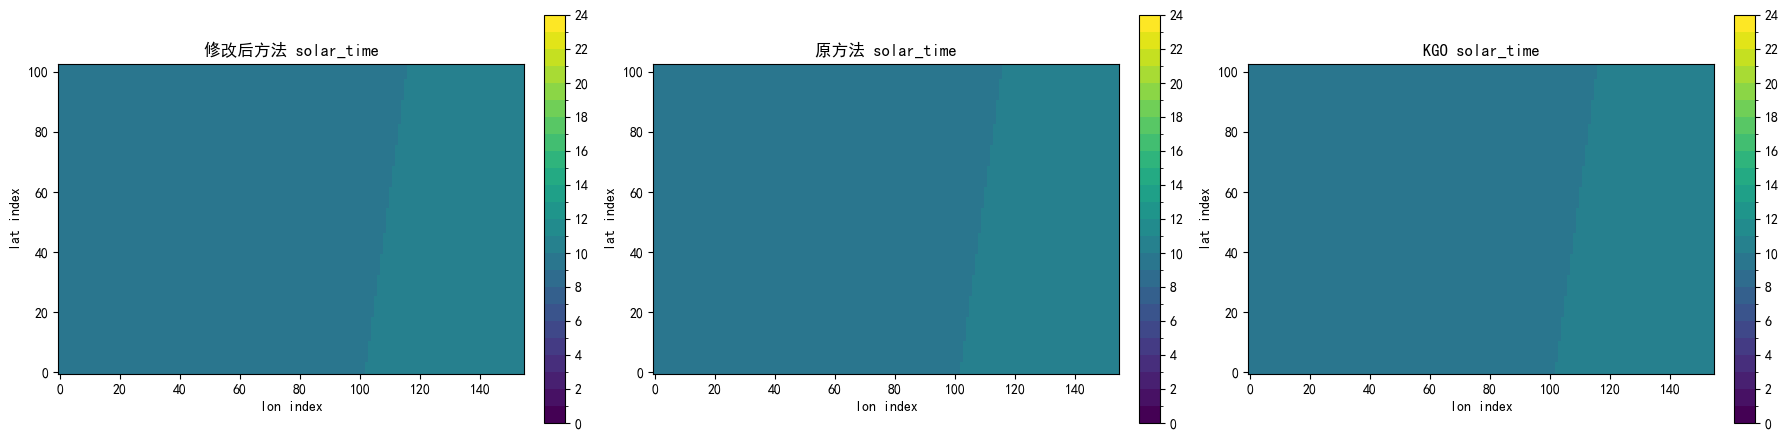

In [6]:
# 三图对比：修改后方法、原方法、KGO（固定 0-24 小时，每小时一档离散色标）
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 solar_time")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 solar_time")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

im2 = axes[2].imshow(k_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[2].set_title("KGO solar_time")
axes[2].set_xlabel("lon index")
axes[2].set_ylabel("lat index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, ticks=solar_ticks)

plt.tight_layout()
plt.show()


### 3.2 GenerateClearskySolarRadiation

`basic`：只给网格，内部用默认海拔和浑浊度。
`with_altitude_and_lt`：再传入真实海拔和 Linke 浑浊度。累积时长从 KGO 的时间边界自动推断。


#### 输入数据绘图

海拔越高、空气越清（Linke 浊度越小），晴空辐射通常越大。


In [7]:
clearsky_root = TEST_ROOT / "generate-clearsky-solar-radiation"
clearsky_alt_path = clearsky_root / "cli_inputs" / "input_surface_altitude_meb.nc"
clearsky_lt_path = clearsky_root / "cli_inputs" / "input_linke_turbidity_meb.nc"
require_files([clearsky_alt_path, clearsky_lt_path], "投影坐标 meb")

# 晴空辐射 basic 场景也用海拔场当目标网格（只要坐标，不要海拔数值）
clearsky_target_grid = meb.read_griddata_from_nc(str(clearsky_alt_path))
surface_altitude_meb = meb.read_griddata_from_nc(str(clearsky_alt_path))
linke_turbidity_meb = meb.read_griddata_from_nc(str(clearsky_lt_path))

# 预处理已把 KGO 时刻写入 meb 的 time 维，这里取出来给算法
clearsky_valid_time = str(
    np.datetime_as_string(np.asarray(clearsky_target_grid.coords["time"].values).ravel()[0], unit="s")
)
clearsky_valid_time_dt = datetime.fromisoformat(clearsky_valid_time)

# 原方法输入：原始测试数据
clearsky_target_cube = iris.load_cube(str(clearsky_root / "surface_altitude.nc"))
clearsky_altitude_cube = iris.load_cube(str(clearsky_root / "surface_altitude.nc"))
clearsky_linke_cube = iris.load_cube(str(clearsky_root / "linke_turbidity.nc"))

print("clearsky_valid_time:", clearsky_valid_time)
print("clearsky_target_grid:", clearsky_target_grid.shape, clearsky_target_grid.dims)
print("surface_altitude_meb:", surface_altitude_meb.shape)
print("linke_turbidity_meb:", linke_turbidity_meb.shape)


clearsky_valid_time: 2022-05-06T00:00:00
clearsky_target_grid: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')
surface_altitude_meb: (1, 1, 1, 1, 103, 155)
linke_turbidity_meb: (1, 1, 1, 1, 103, 155)


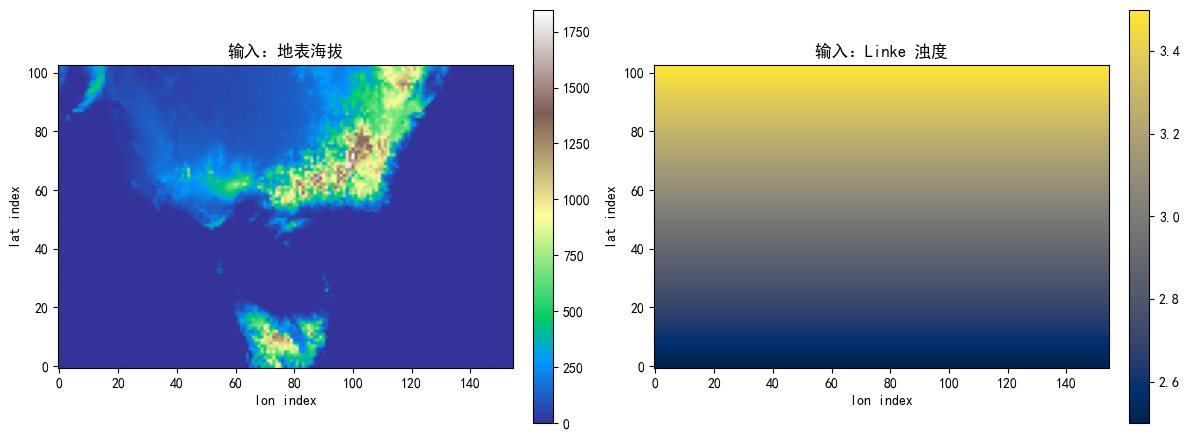

In [8]:
# 输入数据绘图：地表海拔与 Linke 浊度
clearsky_input_surface_altitude_2d = to_2d_values(surface_altitude_meb)
clearsky_input_linke_turbidity_2d = to_2d_values(linke_turbidity_meb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(clearsky_input_surface_altitude_2d, origin="lower", cmap="terrain")
axes[0].set_title("输入：地表海拔")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(clearsky_input_linke_turbidity_2d, origin="lower", cmap="cividis")
axes[1].set_title("输入：Linke 浊度")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


#### 算法运行与数值对比


In [9]:
# 累积时长必须与官方 KGO 一致，否则数值对不上
acc_hours = infer_accumulation_hours_from_kgo(clearsky_root / "basic" / "kgo.nc")
print("inferred accumulation_period_hours:", acc_hours)

# basic：只用网格坐标
clearsky_current_basic = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
)

# with_altitude_and_lt：再给海拔和 Linke 浑浊度
clearsky_current_with_alt_lt = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude=surface_altitude_meb,
    linke_turbidity=linke_turbidity_meb,
)

# 确认 new_title 会写进输出 attrs
clearsky_current_new_title = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    new_title="demo_new_title",
)
assert clearsky_current_new_title.attrs.get("title") == "demo_new_title"

# 原方法现场调用（同一投影样例）
clearsky_original_basic = OrigGenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_cube,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
)
# 原方法（with_altitude_and_lt）
clearsky_original_with_alt_lt = OrigGenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_cube,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude=clearsky_altitude_cube,
    linke_turbidity=clearsky_linke_cube,
)

clearsky_kgo_basic = iris.load_cube(str(clearsky_root / "basic" / "kgo.nc"))
clearsky_kgo_with_alt_lt = iris.load_cube(str(clearsky_root / "with_altitude_and_lt" / "kgo.nc"))

c_clear_basic, k_clear_basic, d_clear_basic_ck = compare_stats(
    clearsky_current_basic, clearsky_kgo_basic, "clearsky basic 修改后方法-KGO"
)
_, o_clear_basic, d_clear_basic_co = compare_stats(
    clearsky_current_basic, clearsky_original_basic, "clearsky basic 修改后方法-原方法"
)
_, _, d_clear_basic_ok = compare_stats(
    clearsky_original_basic, clearsky_kgo_basic, "clearsky basic 原方法-KGO"
)

c_clear_altlt, k_clear_altlt, d_clear_altlt_ck = compare_stats(
    clearsky_current_with_alt_lt,
    clearsky_kgo_with_alt_lt,
    "clearsky with_alt_lt 修改后方法-KGO",
)
_, o_clear_altlt, d_clear_altlt_co = compare_stats(
    clearsky_current_with_alt_lt,
    clearsky_original_with_alt_lt,
    "clearsky with_alt_lt 修改后方法-原方法",
)
_, _, d_clear_altlt_ok = compare_stats(
    clearsky_original_with_alt_lt,
    clearsky_kgo_with_alt_lt,
    "clearsky with_alt_lt 原方法-KGO",
)


inferred accumulation_period_hours: 24
[clearsky basic 修改后方法-KGO] 平均绝对误差=1.433573, 最大绝对误差=8.000000, 均方根误差=1.878505
[clearsky basic 修改后方法-原方法] 平均绝对误差=1.433573, 最大绝对误差=8.000000, 均方根误差=1.878505
[clearsky basic 原方法-KGO] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000
[clearsky with_alt_lt 修改后方法-KGO] 平均绝对误差=1.466333, 最大绝对误差=8.000000, 均方根误差=1.924572
[clearsky with_alt_lt 修改后方法-原方法] 平均绝对误差=1.466333, 最大绝对误差=8.000000, 均方根误差=1.924572
[clearsky with_alt_lt 原方法-KGO] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000


#### 输出对比绘图

第一行是 basic，第二行是带海拔/浑浊度。同一行三张图共用色标，方便看是否长得像。


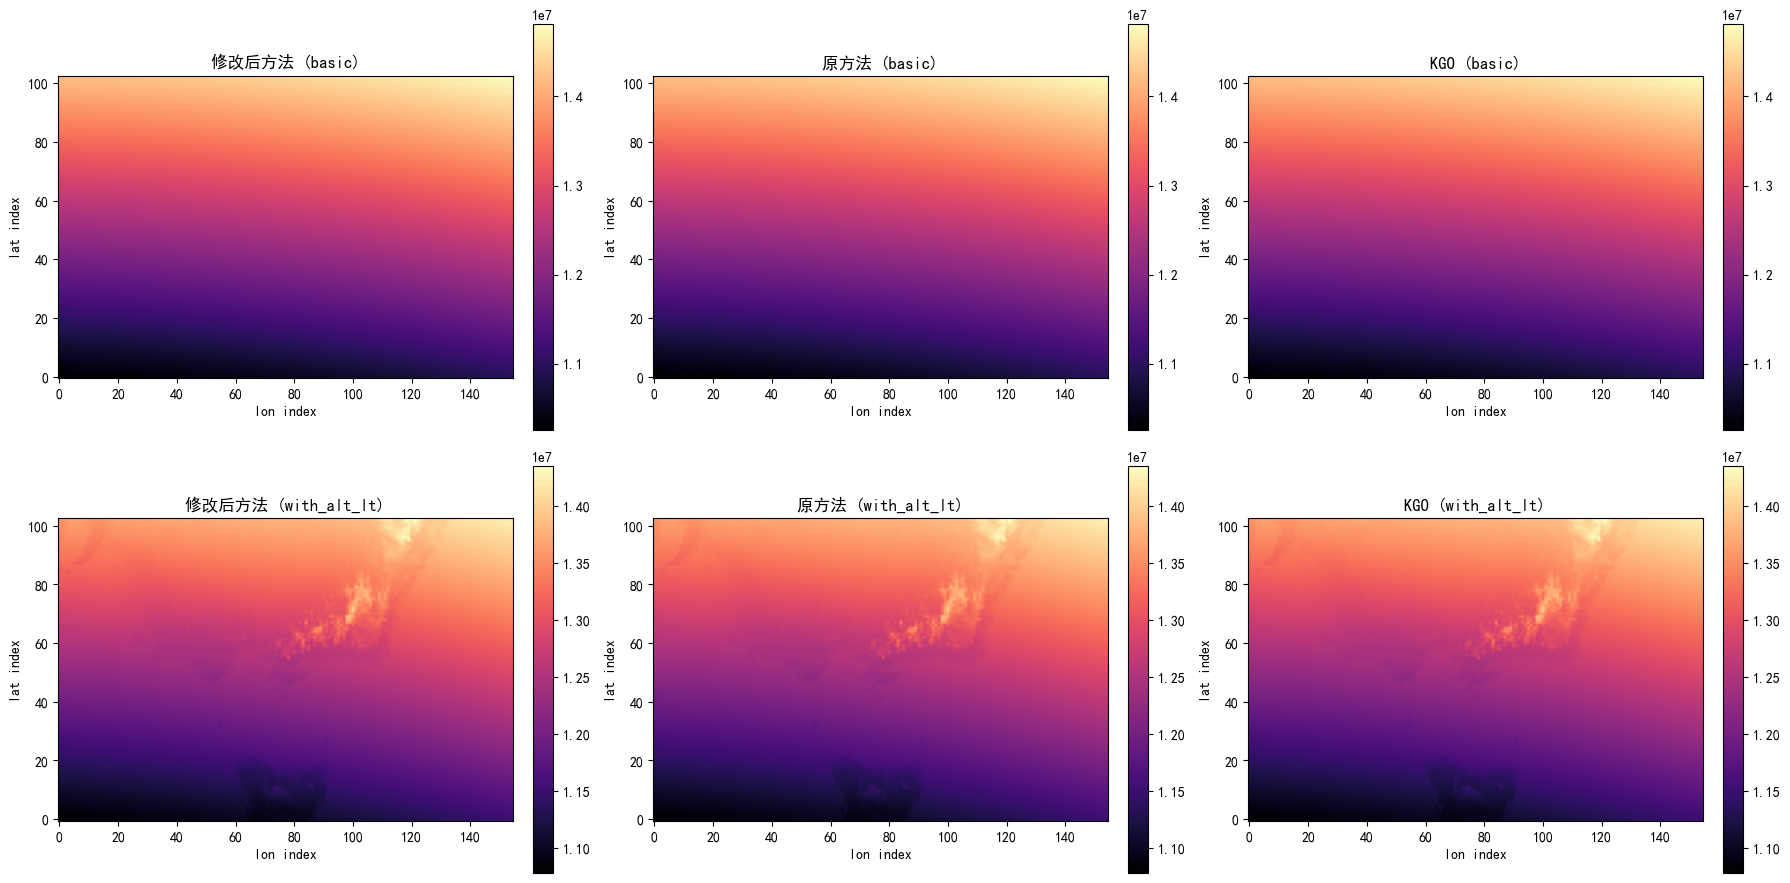

In [10]:
# 六图对比：
# 第一行是 basic 场景（修改后方法、原方法、KGO，统一色标）
# 第二行是 with_altitude_and_lt 场景（修改后方法、原方法、KGO，统一色标）
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

basic_vmin = float(np.nanmin([c_clear_basic.min(), o_clear_basic.min(), k_clear_basic.min()]))
basic_vmax = float(np.nanmax([c_clear_basic.max(), o_clear_basic.max(), k_clear_basic.max()]))

im00 = axes[0, 0].imshow(c_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(o_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(k_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 2].set_title("KGO (basic)")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

altlt_vmin = float(np.nanmin([c_clear_altlt.min(), o_clear_altlt.min(), k_clear_altlt.min()]))
altlt_vmax = float(np.nanmax([c_clear_altlt.max(), o_clear_altlt.max(), k_clear_altlt.max()]))

im10 = axes[1, 0].imshow(c_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(o_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(k_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 2].set_title("KGO (with_alt_lt)")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")

plt.tight_layout()
plt.show()


## 4. 经纬坐标输入

读取 `latlon/` Cube 与 `latlon/cli_inputs/` meb。经纬网格和投影网格的格距不同，**不用投影 KGO 对比**；主判据是同一经纬输入下「修改后方法 vs 原方法」。


### 4.1 GenerateSolarTime


#### 读取经纬输入数据


In [11]:
# Cube 给原方法，meb 给迁移方法
solar_ll_cube_path = solar_root / "latlon" / "surface_altitude.nc"
solar_ll_meb_path = solar_root / "latlon" / "cli_inputs" / "input_target_grid_meb.nc"
require_files([solar_ll_cube_path,solar_ll_meb_path],"经纬坐标输入")

# 修改后插件经纬输入
solar_target_grid_latlon = meb.read_griddata_from_nc(str(solar_ll_meb_path))
# 原方法插件经纬输入
solar_input_latlon_cube = iris.load_cube(str(solar_ll_cube_path))


#### 算法运行与数值对比


In [12]:
# 经纬路径：调用方式与投影相同，只是输入换成经纬网格
solar_current_basic_latlon = GenerateSolarTime().process(
    target_grid=solar_target_grid_latlon,
    time=solar_valid_time_dt,
)
solar_current_new_title_latlon = GenerateSolarTime().process(
    target_grid=solar_target_grid_latlon,
    time=solar_valid_time_dt,
    new_title="demo_new_title",
)
assert solar_current_new_title_latlon.attrs.get("title") == "demo_new_title"

orig_solar_plugin = OrigGenerateSolarTime()
solar_original_basic_latlon_cube = orig_solar_plugin.process(
    solar_input_latlon_cube,
    solar_valid_time_dt,
)
c_solar2, o_solar2, d_solar2_co = compare_stats(
    solar_current_basic_latlon, solar_original_basic_latlon_cube, "solar 修改后方法-原方法"
)


[solar 修改后方法-原方法] 平均绝对误差=0.000000, 最大绝对误差=0.000001, 均方根误差=0.000001


#### 输出对比绘图


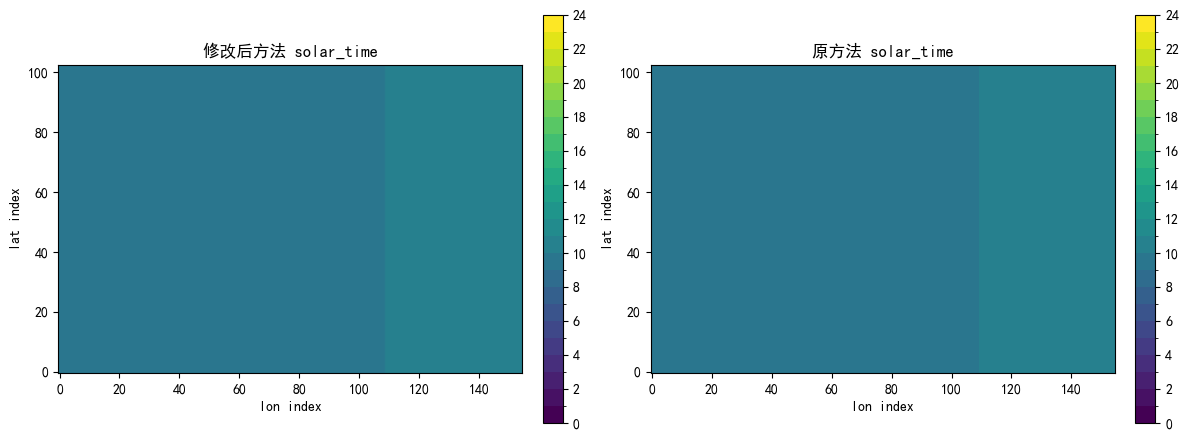

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar2, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 solar_time")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar2, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 solar_time")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

for ax in axes:
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")
plt.tight_layout()
plt.show()


### 4.2 GenerateClearskySolarRadiation


#### 读取经纬输入数据


In [14]:
# Cube 给原方法，meb 给迁移方法
clearsky_ll_alt_cube_path = clearsky_root / "latlon" / "surface_altitude.nc"
clearsky_ll_lt_cube_path = clearsky_root / "latlon" / "linke_turbidity.nc"
clearsky_ll_alt_meb_path = clearsky_root / "latlon" / "cli_inputs" / "input_surface_altitude_meb.nc"
clearsky_ll_lt_meb_path = clearsky_root / "latlon" / "cli_inputs" / "input_linke_turbidity_meb.nc"
require_files(
    [
        clearsky_ll_alt_cube_path,
        clearsky_ll_lt_cube_path,
        clearsky_ll_alt_meb_path,
        clearsky_ll_lt_meb_path,
    ],
    "经纬坐标输入",
)

# 修改后插件方法经纬输入
clearsky_target_grid_latlon = meb.read_griddata_from_nc(str(clearsky_ll_alt_meb_path))
surface_altitude_meb_latlon = meb.read_griddata_from_nc(str(clearsky_ll_alt_meb_path))
linke_turbidity_meb_latlon = meb.read_griddata_from_nc(str(clearsky_ll_lt_meb_path))
# 原方法插件经纬输入
clearsky_surface_altitude_latlon_cube = iris.load_cube(str(clearsky_ll_alt_cube_path))
clearsky_linke_turbidity_latlon_cube = iris.load_cube(str(clearsky_ll_lt_cube_path))


#### 算法运行与数值对比


In [15]:
# 经纬路径同样跑 basic 与 with_altitude_and_lt，只和原方法比
clearsky_current_basic_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
)
clearsky_current_with_alt_lt_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude=surface_altitude_meb_latlon,
    linke_turbidity=linke_turbidity_meb_latlon,
)
clearsky_current_new_title_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    new_title="demo_new_title",
)
assert clearsky_current_new_title_latlon.attrs.get("title") == "demo_new_title"

orig_clearsky_plugin = OrigGenerateClearskySolarRadiation()
clearsky_original_basic_latlon_cube = orig_clearsky_plugin.process(
    target_grid=clearsky_surface_altitude_latlon_cube,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
)
clearsky_original_with_alt_lt_latlon_cube = orig_clearsky_plugin.process(
    target_grid=clearsky_surface_altitude_latlon_cube,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude=clearsky_surface_altitude_latlon_cube,
    linke_turbidity=clearsky_linke_turbidity_latlon_cube,
)
c_clear_basic2, o_clear_basic2, _ = compare_stats(
    clearsky_current_basic_latlon, clearsky_original_basic_latlon_cube, "clearsky basic 修改后方法-原方法"
)
c_clear_altlt2, o_clear_altlt2, _ = compare_stats(
    clearsky_current_with_alt_lt_latlon,
    clearsky_original_with_alt_lt_latlon_cube,
    "clearsky with_alt_lt 修改后方法-原方法",
)


[clearsky basic 修改后方法-原方法] 平均绝对误差=1.402192, 最大绝对误差=9.000000, 均方根误差=1.846506
[clearsky with_alt_lt 修改后方法-原方法] 平均绝对误差=1.442092, 最大绝对误差=10.000000, 均方根误差=1.905421


#### 输出对比绘图


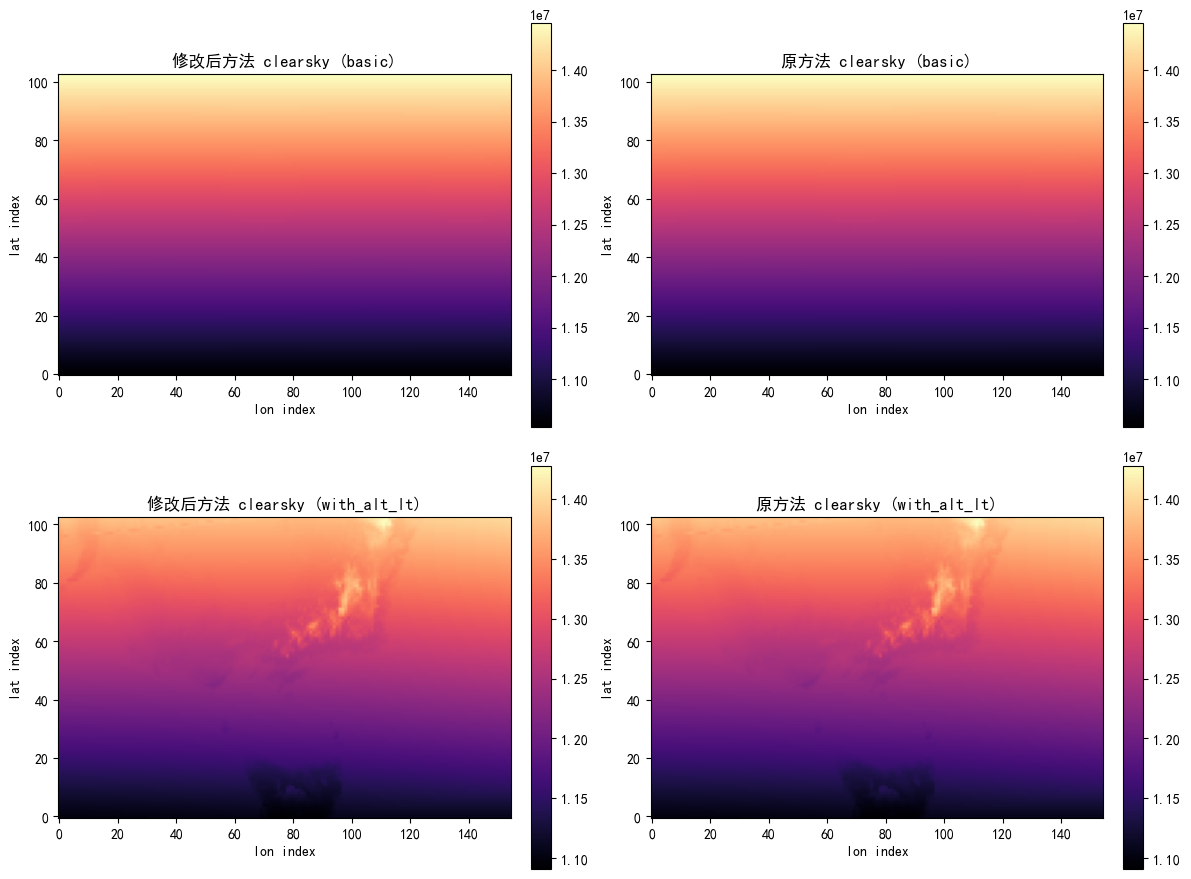

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

basic_vmin = float(np.nanmin([c_clear_basic2.min(), o_clear_basic2.min()]))
basic_vmax = float(np.nanmax([c_clear_basic2.max(), o_clear_basic2.max()]))
im00 = axes[0, 0].imshow(c_clear_basic2, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 clearsky (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)
im01 = axes[0, 1].imshow(o_clear_basic2, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 clearsky (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

altlt_vmin = float(np.nanmin([c_clear_altlt2.min(), o_clear_altlt2.min()]))
altlt_vmax = float(np.nanmax([c_clear_altlt2.max(), o_clear_altlt2.max()]))
im10 = axes[1, 0].imshow(c_clear_altlt2, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 clearsky (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)
im11 = axes[1, 1].imshow(o_clear_altlt2, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 clearsky (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")
plt.tight_layout()
plt.show()


## 5. CLI 示例

CLI 脚本的入口函数 `process()` 接收的是 **nc 文件路径**（不是已经读好的数组）。
脚本内部会自己读盘、调用算法，并把结果写到与脚本底部相同的 `cli_outputs/` 文件。

下面用投影坐标的 `cli_inputs/` 演示调用，并与 KGO / 原 CLI 结果对照。终端里也可以直接跑（先改脚本底部的路径）：

```text
python generate_derived_solar_fields/cli/cal_generate_solar_time.py
python generate_derived_solar_fields/cli/cal_generate_clearsky_solar_radiation.py
```


### 5.1 GenerateSolarTime

对比三路：修改后 CLI | 原方法 CLI | KGO。写出文件名与 `cal_generate_solar_time.py` 底部一致。


已写出: D:\workspace\improver\generate_derived_solar_fields\test_data\generate-solar-time\cli_outputs\cal_solar_time_result.nc
[solar cli 修改后方法-原方法] 平均绝对误差=0.000000, 最大绝对误差=0.000002, 均方根误差=0.000001
[solar cli 修改后方法-kgo] 平均绝对误差=0.000000, 最大绝对误差=0.000002, 均方根误差=0.000001
[solar cli 原方法-kgo] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000


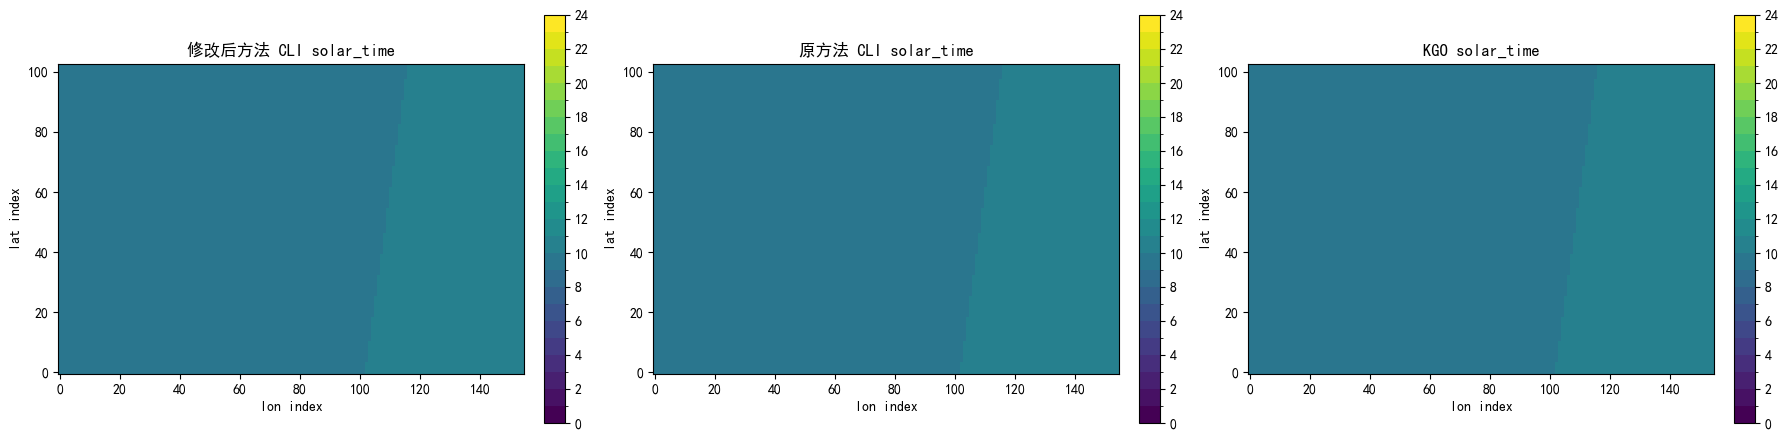

In [17]:
from generate_derived_solar_fields.cli.cal_generate_solar_time import process as cli_solar_process

solar_cli_root = TEST_ROOT / "generate-solar-time"
solar_cli_input = solar_cli_root / "cli_inputs" / "input_target_grid_meb.nc"
solar_cli_original_output = solar_cli_root / "cli_outputs" / "original_cli_solar_time.nc"
solar_kgo = solar_cli_root / "basic" / "kgo.nc"
# 写出路径与 cal_generate_solar_time.py 脚本底部一致
solar_cli_output = solar_cli_root / "cli_outputs" / "cal_solar_time_result.nc"

# 修改后方法cli调用
solar_cli_current = cli_solar_process(
    target_grid_path=str(solar_cli_input),
    time=solar_valid_time_dt,
    output_path=str(solar_cli_output),
)
print(f"已写出: {solar_cli_output}")

# 原方法 CLI 与 KGO 结果（直接读取 nc）
solar_cli_original = iris.load_cube(str(solar_cli_original_output))
solar_cli_kgo = iris.load_cube(str(solar_kgo))

# 数值统计
c_solar_cli, o_solar_cli, _ = compare_stats(
    solar_cli_current,
    solar_cli_original,
    "solar cli 修改后方法-原方法",
)
_, k_solar_cli, _ = compare_stats(
    solar_cli_current,
    solar_cli_kgo,
    "solar cli 修改后方法-kgo",
)
_, _, _ = compare_stats(
    solar_cli_original,
    solar_cli_kgo,
    "solar cli 原方法-kgo",
)

# 三图统一色标对比
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 CLI solar_time")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 CLI solar_time")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

im2 = axes[2].imshow(k_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[2].set_title("KGO solar_time")
axes[2].set_xlabel("lon index")
axes[2].set_ylabel("lat index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, ticks=solar_ticks)

plt.tight_layout()
plt.show()


### 5.2 GenerateClearskySolarRadiation

`basic` 单独写一个文件，避免覆盖脚本默认的 `with_altitude_and_lt` 结果。


已写出: D:\workspace\improver\generate_derived_solar_fields\test_data\generate-clearsky-solar-radiation\cli_outputs\cal_clearsky_solar_radiation_basic_result.nc
已写出: D:\workspace\improver\generate_derived_solar_fields\test_data\generate-clearsky-solar-radiation\cli_outputs\cal_clearsky_solar_radiation_result.nc
[clearsky cli basic 修改后方法-原方法] 平均绝对误差=1.433573, 最大绝对误差=8.000000, 均方根误差=1.878505
[clearsky cli basic 修改后方法-kgo] 平均绝对误差=1.433573, 最大绝对误差=8.000000, 均方根误差=1.878505
[clearsky cli basic 原方法-kgo] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000
[clearsky cli with_alt_lt 修改后方法-原方法] 平均绝对误差=1.466333, 最大绝对误差=8.000000, 均方根误差=1.924572
[clearsky cli with_alt_lt 修改后方法-kgo] 平均绝对误差=1.466333, 最大绝对误差=8.000000, 均方根误差=1.924572
[clearsky cli with_alt_lt 原方法-kgo] 平均绝对误差=0.000000, 最大绝对误差=0.000000, 均方根误差=0.000000


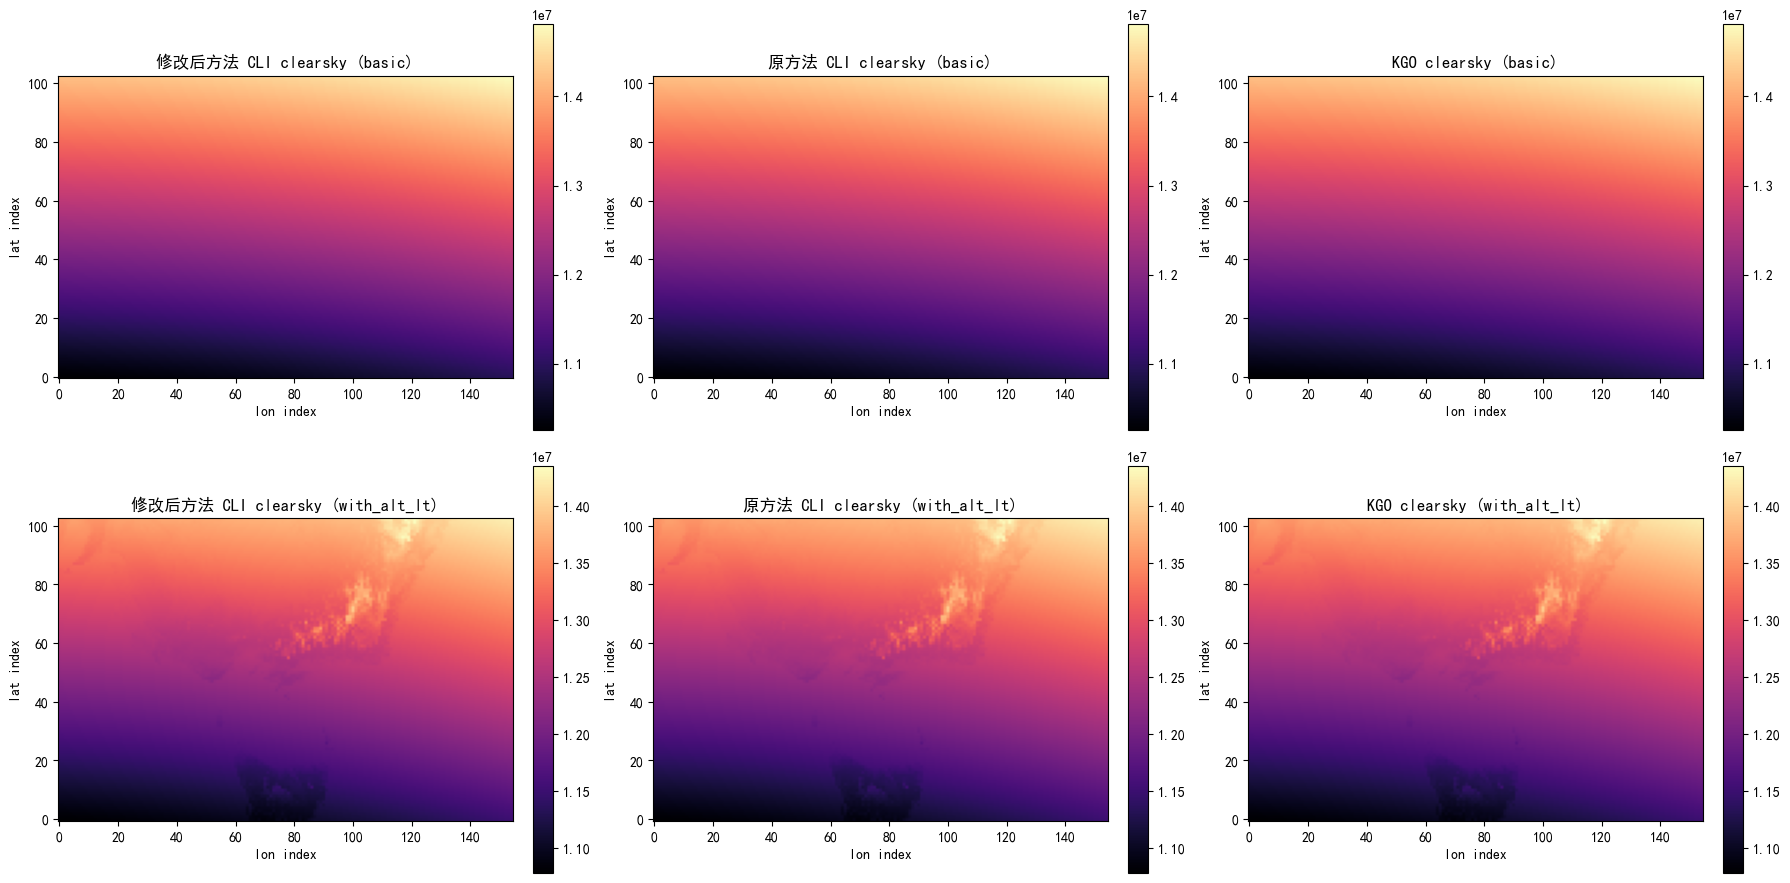

In [18]:
from generate_derived_solar_fields.cli.cal_generate_clearsky_solar_radiation import (
    process as cli_clearsky_process,
)

clearsky_cli_root = TEST_ROOT / "generate-clearsky-solar-radiation"
clearsky_cli_input_root = clearsky_cli_root / "cli_inputs"
clearsky_cli_output_root = clearsky_cli_root / "cli_outputs"

surface_altitude_path = clearsky_cli_input_root / "input_surface_altitude_meb.nc"
linke_turbidity_path = clearsky_cli_input_root / "input_linke_turbidity_meb.nc"

# basic 场景单独写出，避免覆盖脚本默认的 with_alt_lt 结果
clearsky_cli_basic_out = clearsky_cli_output_root / "cal_clearsky_solar_radiation_basic_result.nc"
# 写出路径与 cal_generate_clearsky_solar_radiation.py 脚本底部一致
clearsky_cli_altlt_out = clearsky_cli_output_root / "cal_clearsky_solar_radiation_result.nc"

# 修改后方法cli调用
clearsky_cli_current_basic = cli_clearsky_process(
    target_grid_path=str(surface_altitude_path),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    output_path=str(clearsky_cli_basic_out),
)
print(f"已写出: {clearsky_cli_basic_out}")

# 修改后方法cli调用
clearsky_cli_current_altlt = cli_clearsky_process(
    target_grid_path=str(surface_altitude_path),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude_path=str(surface_altitude_path),
    linke_turbidity_path=str(linke_turbidity_path),
    output_path=str(clearsky_cli_altlt_out),
)
print(f"已写出: {clearsky_cli_altlt_out}")

# 原方法 CLI 输出
clearsky_cli_original_basic = iris.load_cube(str(clearsky_cli_output_root / "original_cli_clearsky_basic.nc"))
clearsky_cli_original_altlt = iris.load_cube(str(clearsky_cli_output_root / "original_cli_clearsky_with_alt_lt.nc"))

# KGO
clearsky_cli_kgo_basic = iris.load_cube(str(clearsky_cli_root / "basic" / "kgo.nc"))
clearsky_cli_kgo_altlt = iris.load_cube(str(clearsky_cli_root / "with_altitude_and_lt" / "kgo.nc"))

# 数值统计
c_clear_cli_basic, o_clear_cli_basic, _ = compare_stats(
    clearsky_cli_current_basic,
    clearsky_cli_original_basic,
    "clearsky cli basic 修改后方法-原方法",
)
_, k_clear_cli_basic, _ = compare_stats(
    clearsky_cli_current_basic,
    clearsky_cli_kgo_basic,
    "clearsky cli basic 修改后方法-kgo",
)
_, _, _ = compare_stats(
    clearsky_cli_original_basic,
    clearsky_cli_kgo_basic,
    "clearsky cli basic 原方法-kgo",
)

c_clear_cli_altlt, o_clear_cli_altlt, _ = compare_stats(
    clearsky_cli_current_altlt,
    clearsky_cli_original_altlt,
    "clearsky cli with_alt_lt 修改后方法-原方法",
)
_, k_clear_cli_altlt, _ = compare_stats(
    clearsky_cli_current_altlt,
    clearsky_cli_kgo_altlt,
    "clearsky cli with_alt_lt 修改后方法-kgo",
)
_, _, _ = compare_stats(
    clearsky_cli_original_altlt,
    clearsky_cli_kgo_altlt,
    "clearsky cli with_alt_lt 原方法-kgo",
)

# 三图对比（两行场景）
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

basic_vmin = float(
    np.nanmin([c_clear_cli_basic.min(), o_clear_cli_basic.min(), k_clear_cli_basic.min()])
)
basic_vmax = float(
    np.nanmax([c_clear_cli_basic.max(), o_clear_cli_basic.max(), k_clear_cli_basic.max()])
)

im00 = axes[0, 0].imshow(c_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 CLI clearsky (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(o_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 CLI clearsky (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(k_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 2].set_title("KGO clearsky (basic)")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

altlt_vmin = float(
    np.nanmin([c_clear_cli_altlt.min(), o_clear_cli_altlt.min(), k_clear_cli_altlt.min()])
)
altlt_vmax = float(
    np.nanmax([c_clear_cli_altlt.max(), o_clear_cli_altlt.max(), k_clear_cli_altlt.max()])
)

im10 = axes[1, 0].imshow(c_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 CLI clearsky (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(o_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 CLI clearsky (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(k_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 2].set_title("KGO clearsky (with_alt_lt)")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")

plt.tight_layout()
plt.show()
